In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df = pd.read_csv('agriculture_yield_dataset.csv')

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17


In [3]:
# Question 1 Data set overview

print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 10 Records:")
print(df.head(10))

Shape of Dataset:
(1500, 8)

Column Names:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']

First 10 Records:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5           29.4           89.3            

In [4]:
# Question 2 Data Types and Missing Values

print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Data Types:
rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing Values:
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64


In [5]:
# Question 3 Descriptive Statistics

stats = df.describe()

print(stats)

print("\nHighest Mean:")
print(stats.loc['mean'].idxmax())

print("\nHighest Standard Deviation:")
print(stats.loc['std'].idxmax())

       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max       8.00000

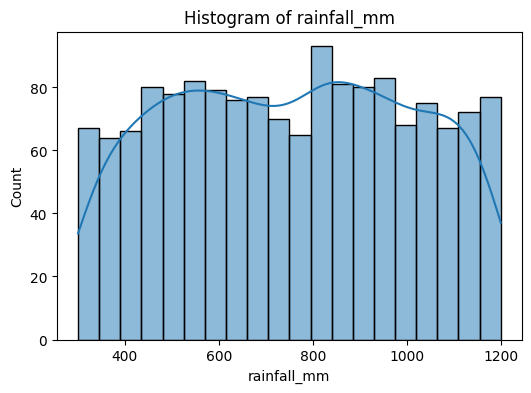

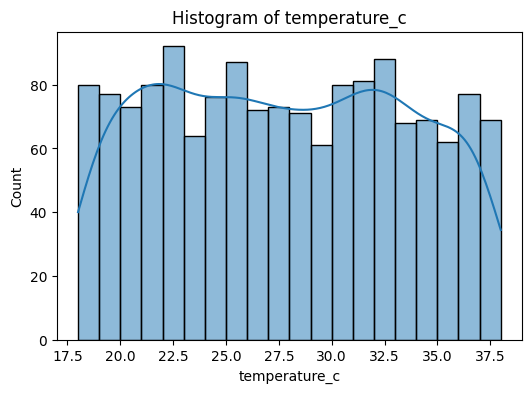

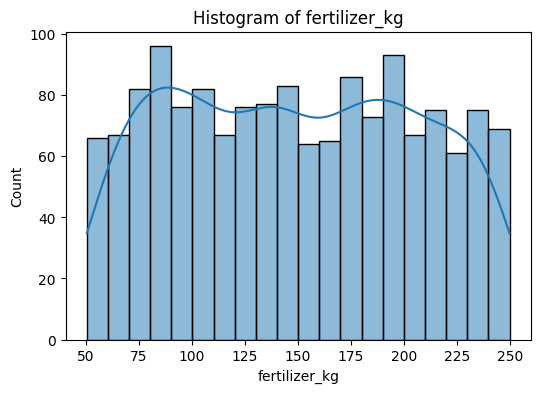

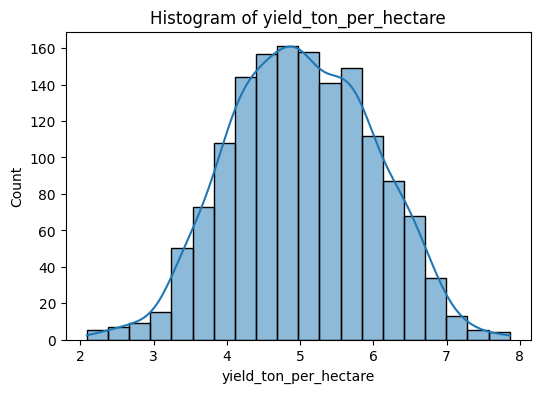

In [8]:
# Question 4 EDA

numerical_cols = [
    'rainfall_mm',
    'temperature_c',
    'fertilizer_kg',
    'yield_ton_per_hectare'
]

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=20, kde=True)
    plt.title(f'Histogram of {col}')
    plt.show()

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


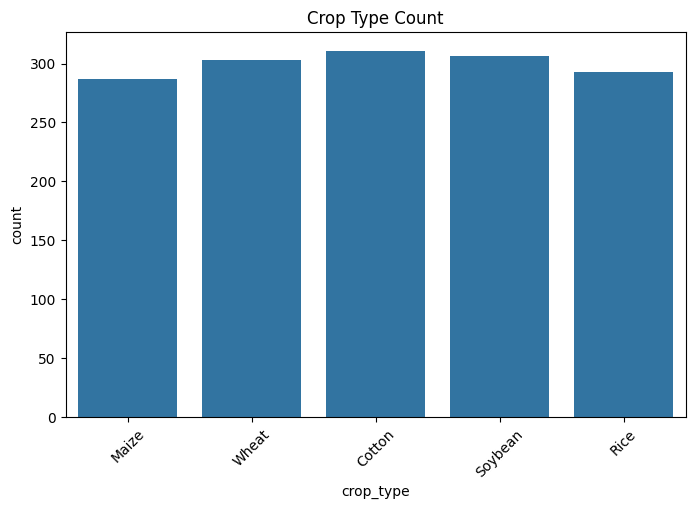

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


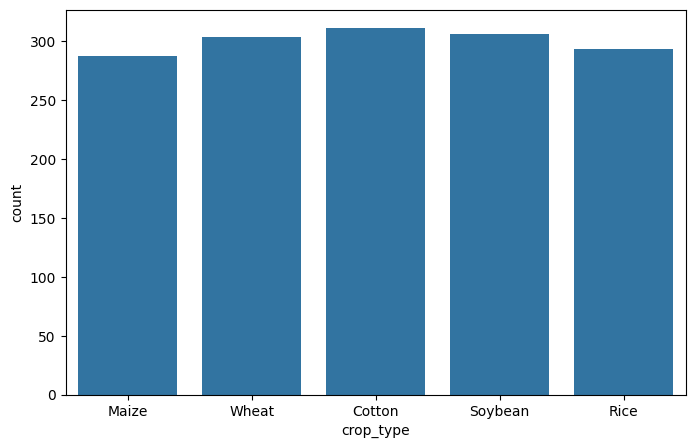

In [10]:
# Question 5 Crop Type Analysis

print(df['crop_type'].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(x='crop_type', data=df)
plt.title('Crop Type Count')
plt.xticks(rotation=45)
plt.show()

print(df['crop_type'].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(x='crop_type', data=df)
plt.show()

Frequency of each soil type:
soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


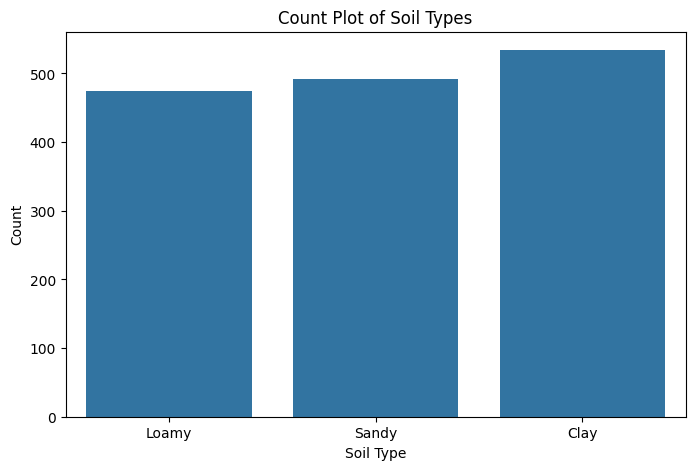


Most Common Soil Type:
Clay


In [11]:
# Question 6 Soil Type Analysis


# Frequency of each soil type
soil_frequency = df['soil_type'].value_counts()

print("Frequency of each soil type:")
print(soil_frequency)

# Count Plot
plt.figure(figsize=(8,5))
sns.countplot(x='soil_type', data=df)

plt.title("Count Plot of Soil Types")
plt.xlabel("Soil Type")
plt.ylabel("Count")
plt.show()

# Most common soil type
most_common_soil = df['soil_type'].value_counts().idxmax()

print("\nMost Common Soil Type:")
print(most_common_soil)



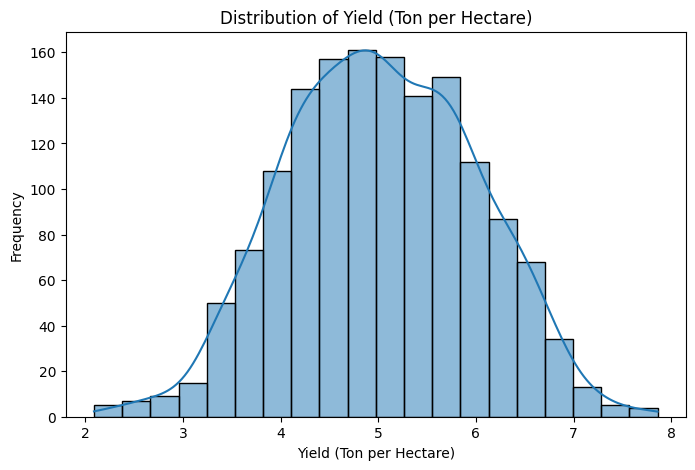

In [12]:
# Question 7 Yield Distribution

# Histogram of Yield

plt.figure(figsize=(8,5))
sns.histplot(df['yield_ton_per_hectare'], bins=20, kde=True)

plt.title("Distribution of Yield (Ton per Hectare)")
plt.xlabel("Yield (Ton per Hectare)")
plt.ylabel("Frequency")

plt.show()

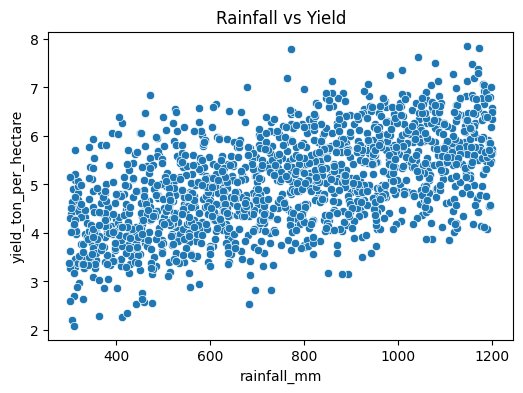

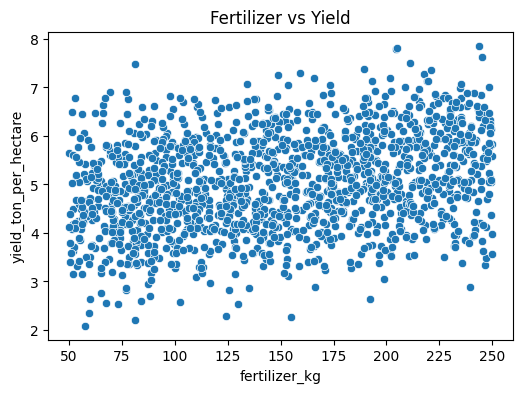

In [13]:
# Question 8 Scatter Plot Analysis

plt.figure(figsize=(6,4))
sns.scatterplot(x='rainfall_mm',
                y='yield_ton_per_hectare',
                data=df)
plt.title('Rainfall vs Yield')
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x='fertilizer_kg',
                y='yield_ton_per_hectare',
                data=df)
plt.title('Fertilizer vs Yield')
plt.show()

                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

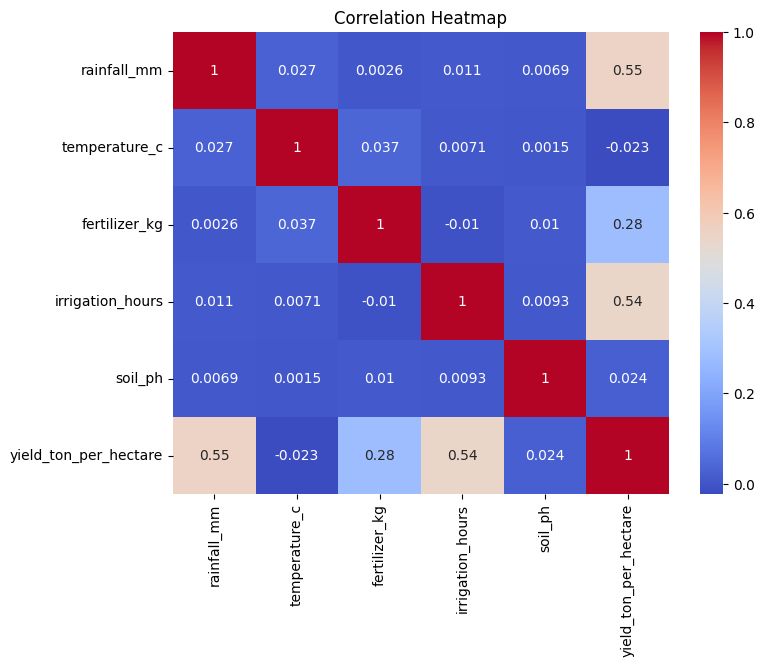

In [14]:
# Question 9 Correlation Analysis

numeric_df = df.select_dtypes(include=np.number)

corr_matrix = numeric_df.corr()

print(corr_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [15]:
# Question 10  Group-Based Analysis

crop_yield = df.groupby('crop_type')['yield_ton_per_hectare'].mean()
soil_yield = df.groupby('soil_type')['yield_ton_per_hectare'].mean()

print("Average Yield by Crop Type")
print(crop_yield)

print("\nAverage Yield by Soil Type")
print(soil_yield)

print("\nBest Crop:")
print(crop_yield.idxmax())

print("\nBest Soil:")
print(soil_yield.idxmax())

Average Yield by Crop Type
crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64

Average Yield by Soil Type
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

Best Crop:
Rice

Best Soil:
Loamy


In [16]:
# Question 11 Feature Encoding

categorical_cols = ['crop_type', 'soil_type']

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print(df_encoded.head())

   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Maize  crop_type_Rice  crop_type_Soybean  \
0                   5.92             True           False              False   
1                   6.24             True           False              False   
2                   4.77            False           False              False   
3                   4.04             True           False              False   
4                   5.17            False           False              False   

   crop_type_Wheat  soil_type_Loamy  soil_type_Sandy  
0            

In [17]:
# Question 12 Feature Selection
X = df_encoded.drop('yield_ton_per_hectare', axis=1)

y = df_encoded['yield_ton_per_hectare']

print("Target Variable:")
print('yield_ton_per_hectare')

Target Variable:
yield_ton_per_hectare


In [18]:
# Question 13 Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1200, 11)
X_test: (300, 11)
y_train: (1200,)
y_test: (300,)


In [19]:
# Question 14 Linear Regression Model

model = LinearRegression()

model.fit(X_train, y_train)

print("Intercept:")
print(model.intercept_)

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("\nCoefficients:")
print(coefficients)

highest_feature = coefficients.loc[
    coefficients['Coefficient'].idxmax()
]

print("\nFeature with Highest Positive Coefficient:")
print(highest_feature)

Intercept:
1.587132027736121

Coefficients:
              Feature  Coefficient
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
2       fertilizer_kg     0.004978
3    irrigation_hours     0.198327
4             soil_ph     0.004901
5     crop_type_Maize     0.238931
6      crop_type_Rice     0.863993
7   crop_type_Soybean     0.481719
8     crop_type_Wheat     0.348474
9     soil_type_Loamy     0.302974
10    soil_type_Sandy    -0.490933

Feature with Highest Positive Coefficient:
Feature        crop_type_Rice
Coefficient          0.863993
Name: 6, dtype: object
